# 04 — Analysis & Findings
**BUSI 1783 Individual Project — Jay Panchal (001495232)**

This notebook contains the full analysis: a descriptive pre/post comparison, the two regression models (each with a post-ETF dummy and a sentiment × dummy interaction term, following the supervisor's guidance), and robustness checks. Each model reports the complete regression output first, followed by a written interpretation.

**Modelling approach.** Rather than splitting the data and running separate pre/post regressions, a single pooled model is used with a post-ETF dummy and a `sentiment × dummy` interaction term. The coefficient on that interaction is the direct test of the research question: whether the sentiment–volatility relationship changed after the ETF. The earlier split-sample Chow-test approach is retained only as a supplementary robustness check in section 4.6.

## 4.1 Setup
Load the analysis dataset and define the ETF cut-off and period label.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

# Load the analysis dataset produced by notebook 03
df = pd.read_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\analysis_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# ETF cut-off (first spot-ETF trading day)
etf_date = pd.Timestamp('2024-01-10')
df['period'] = np.where(df['date'] < etf_date,
                        'Pre-ETF (2022-2023)', 'Post-ETF (2024-2025)')

print(f'Loaded {len(df)} rows, {df["date"].min().date()} to {df["date"].max().date()}')

Loaded 1452 rows, 2022-01-09 to 2025-12-30


## 4.2 Descriptive comparison (pre vs post)
Before testing predictive relationships, this section asks a simpler descriptive question: did the Bitcoin conversation itself change after the ETF? The table compares mean sentiment, post volume and sentiment dispersion across the two periods, and the chart plots mean sentiment over time.

DESCRIPTIVE COMPARISON: Pre vs Post ETF Approval
period              Post-ETF (2024-2025)  Pre-ETF (2022-2023)
mean_sentiment                    0.1933               0.1673
median_sentiment                  0.1946               0.1631
mean_post_volume                223.7975             180.1792
mean_sentiment_std                0.4601               0.4312
n_days                          721.0000             731.0000


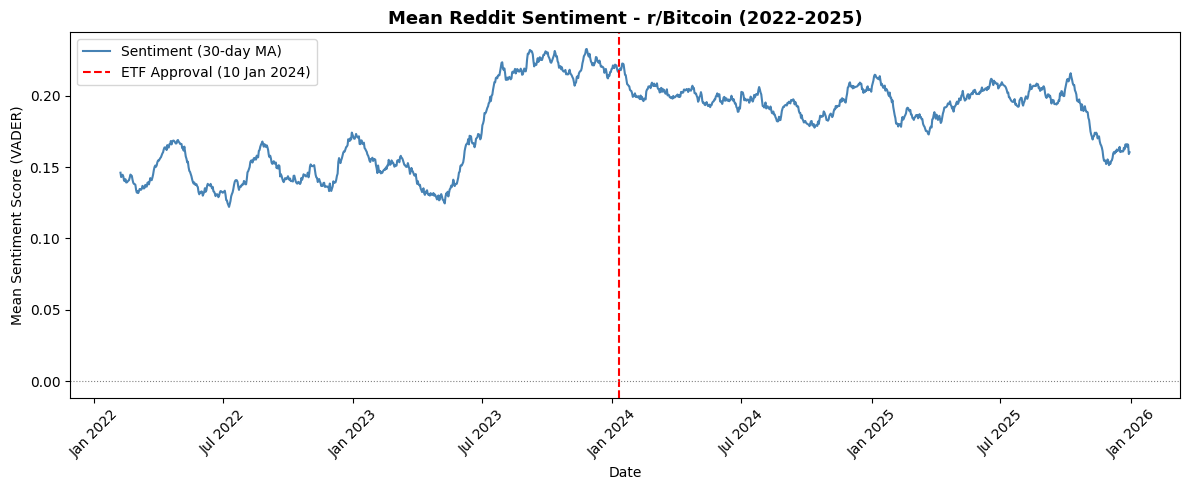

In [2]:
# Descriptive statistics: pre vs post
desc = df.groupby('period').agg(
    mean_sentiment=('sentiment_mean', 'mean'),
    median_sentiment=('sentiment_mean', 'median'),
    mean_post_volume=('post_volume', 'mean'),
    mean_sentiment_std=('sentiment_std', 'mean'),
    n_days=('date', 'count')
).round(4)

print('=' * 60)
print('DESCRIPTIVE COMPARISON: Pre vs Post ETF Approval')
print('=' * 60)
print(desc.T.to_string())

# Chart: mean sentiment over time with ETF line
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['sentiment_mean'].rolling(30).mean(),
        color='steelblue', linewidth=1.5, label='Sentiment (30-day MA)')
ax.axvline(etf_date, color='red', linestyle='--', linewidth=1.5,
           label='ETF Approval (10 Jan 2024)')
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
ax.set_title('Mean Reddit Sentiment - r/Bitcoin (2022-2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Mean Sentiment Score (VADER)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig('sentiment_trend.png', dpi=150); plt.show()

**Interpretation.** After the ETF, mean sentiment rose from 0.167 to 0.193 (about a 15% increase); both periods are positive, consistent with an optimistic holder community. Average daily posts rose from roughly 180 to 224 (about 24% more discussion), and sentiment dispersion increased slightly (0.431 to 0.460). The chart shows sentiment climbing through 2023, peaking around the ETF line, then settling into a higher, steadier band. This is a descriptive shift in the conversation, not evidence of a causal effect — the predictive question is tested in the models below. The direction is consistent with behavioural-finance accounts in which a major legitimising event shifts retail mood (e.g. Baker and Wurgler on investor sentiment).

## 4.3 Price and volatility trend across the ETF line
This section shows the price and volatility series across the cut-off and summarises volatility in each period.

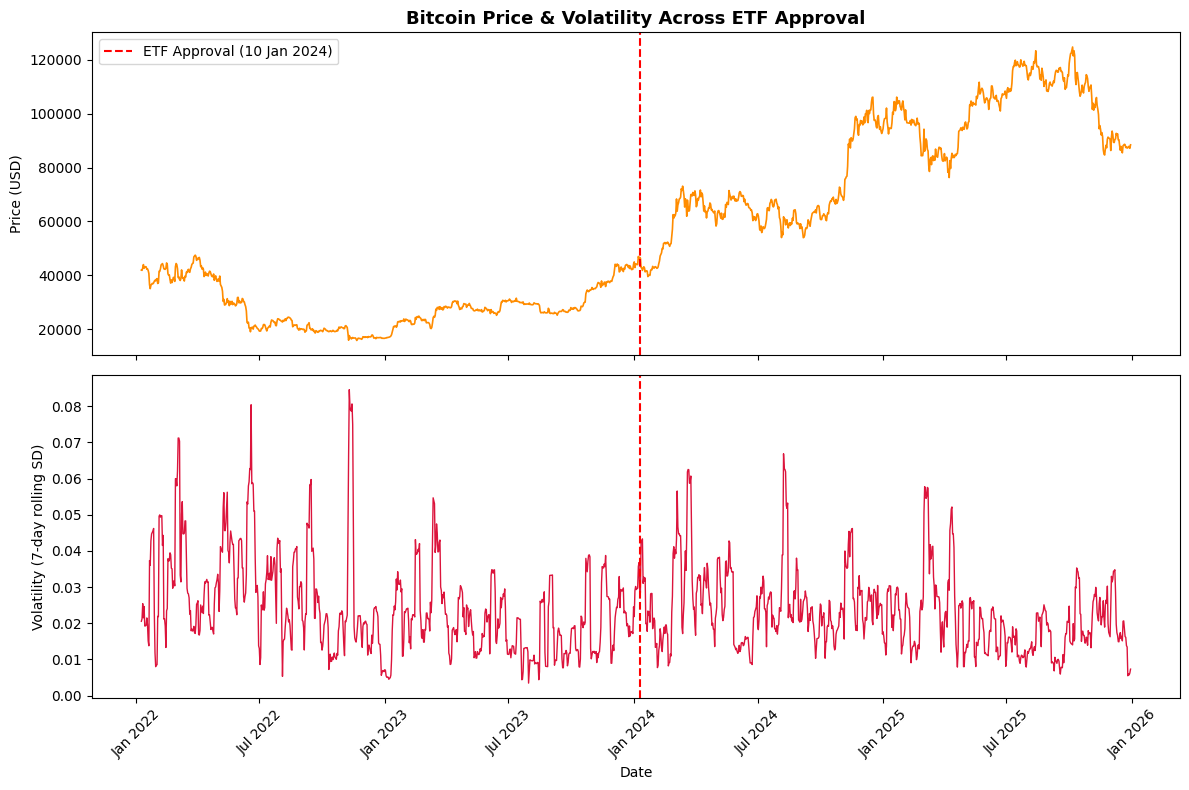


Volatility: Pre vs Post ETF
period  Post-ETF (2024-2025)  Pre-ETF (2022-2023)
mean                  0.0230               0.0250
median                0.0213               0.0223
std                   0.0107               0.0137


In [3]:
# ── PRICE + VOLATILITY TREND ACROSS ETF LINE ──────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Price
ax1.plot(df['date'], df['price'], color='darkorange', linewidth=1.2)
ax1.axvline(etf_date, color='red', linestyle='--', linewidth=1.5, label='ETF Approval (10 Jan 2024)')
ax1.set_title('Bitcoin Price & Volatility Across ETF Approval', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend()

# Volatility
ax2.plot(df['date'], df['volatility'], color='crimson', linewidth=1.0)
ax2.axvline(etf_date, color='red', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Volatility (7-day rolling SD)')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('price_volatility_trend.png', dpi=150)
plt.show()

# Quick pre/post volatility summary
vol_summary = df.groupby('period')['volatility'].agg(['mean', 'median', 'std']).round(4)
print("\nVolatility: Pre vs Post ETF")
print(vol_summary.T.to_string())

**Interpretation.** Price is broadly flat pre-ETF (roughly $20k–$45k) and then rises strongly after the cut-off, exceeding $120k by late 2025. Mean volatility falls slightly post-ETF (0.0250 to 0.0230), and its dispersion tightens (standard deviation 0.0137 to 0.0107): the large pre-ETF spikes become fewer and smaller. The pattern is consistent with an institutionalisation narrative — a larger, more mature market with steadier, less retail-driven behaviour — which provides the motivation for testing whether retail sentiment lost predictive power over volatility.

## 4.4 Model 1 — Volatility
Dependent variable: 7-day rolling volatility. Predictors: lagged sentiment, lagged volatility, post-ETF dummy, the sentiment × dummy interaction, and two controls (lagged post volume and lagged sentiment dispersion). Newey-West (HAC) standard errors are used to account for autocorrelation (justified formally in section 4.6). The full regression output is shown first, then interpreted.

In [4]:
import statsmodels.api as sm

# ── MODEL 1: Volatility with dummy + interaction + controls ──────
df_m = df.copy()

# Post-ETF dummy (1 = post, 0 = pre)
df_m['dummy'] = (df_m['date'] >= etf_date).astype(int)

# Interaction term: sentiment_lag1 × dummy
df_m['sent_x_dummy'] = df_m['sentiment_lag1'] * df_m['dummy']

# Build the model
predictors = ['sentiment_lag1', 'volatility_lag1', 'dummy', 'sent_x_dummy',
              'volume_lag1', 'sentiment_std_lag1']

model_df = df_m[['volatility'] + predictors].dropna()

X = sm.add_constant(model_df[predictors])
y = model_df['volatility']

# Fit with Newey-West robust standard errors (handles autocorrelation)
model1 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 7})

print("=" * 70)
print("MODEL 1: Volatility ~ Sentiment + Dummy + Interaction + Controls")
print("=" * 70)
print(model1.summary())

print("\n" + "=" * 70)
print("KEY RESULT — The interaction term (sent_x_dummy):")
print("=" * 70)
coef = model1.params['sent_x_dummy']
pval = model1.pvalues['sent_x_dummy']
print(f"Coefficient: {coef:.5f}")
print(f"P-value: {pval:.4f}")
print(f"Interpretation: This tests whether sentiment's effect on volatility")
print(f"CHANGED after the ETF. Significant = relationship changed.")

MODEL 1: Volatility ~ Sentiment + Dummy + Interaction + Controls
                            OLS Regression Results                            
Dep. Variable:             volatility   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     642.3
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:44:06   Log-Likelihood:                 5562.8
No. Observations:                1452   AIC:                        -1.111e+04
Df Residuals:                    1445   BIC:                        -1.107e+04
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

**Interpretation.** Lagged volatility dominates the model (coefficient 0.882, p < 0.001), reflecting volatility clustering, and accounts for most of the R² of 0.818. Lagged sentiment is negative and significant (−0.0095, p = 0.034): in the pre-ETF period, higher sentiment is associated with slightly lower next-day volatility. Lagged post volume is a significant control (p = 0.001), which justifies its inclusion. Critically, the **sentiment × dummy interaction is not significant** (0.0011, p = 0.856): once volatility clustering and volume are controlled for, there is no detectable change in the sentiment–volatility relationship after the ETF. The post-ETF dummy itself is also insignificant (p = 0.635). The large condition number reflects the expected correlation between the interaction term and its components and is not treated as a substantive problem. The honest reading is that the fully-controlled model provides no evidence that the ETF changed sentiment's predictive relationship with volatility.

## 4.5 Model 2 — Returns
Dependent variable: daily returns. The proposal specified predicting price levels, but raw price is non-stationary (confirmed by the ADF test in section 4.6), which would make a price-level regression invalid. Returns are used instead. *This change should be confirmed with the supervisor.* Same predictor set as Model 1, plus contemporaneous post volume, with HAC standard errors.

In [5]:
# ── MODEL 2: Returns with dummy + interaction + controls ─────────
# Using returns (stationary) instead of raw price
df_m['sent_x_dummy'] = df_m['sentiment_lag1'] * df_m['dummy']

predictors2 = ['sentiment_lag1', 'volatility_lag1', 'dummy', 'sent_x_dummy',
               'volume_lag1', 'post_volume', 'sentiment_std_lag1']

model_df2 = df_m[['return'] + predictors2].dropna()

X2 = sm.add_constant(model_df2[predictors2])
y2 = model_df2['return']

model2 = sm.OLS(y2, X2).fit(cov_type='HAC', cov_kwds={'maxlags': 7})

print("=" * 70)
print("MODEL 2: Returns ~ Sentiment + Dummy + Interaction + Controls")
print("=" * 70)
print(model2.summary())

MODEL 2: Returns ~ Sentiment + Dummy + Interaction + Controls
                            OLS Regression Results                            
Dep. Variable:                 return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6426
Date:                Mon, 13 Jul 2026   Prob (F-statistic):              0.721
Time:                        17:44:09   Log-Likelihood:                 3188.9
No. Observations:                1452   AIC:                            -6362.
Df Residuals:                    1444   BIC:                            -6320.
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

**Interpretation.** No predictor is significant and the R² is essentially zero (0.004). This is the expected result under the Efficient Market Hypothesis: if lagged public sentiment reliably predicted next-day returns, trading would arbitrage the effect away. The contrast with Model 1 is itself informative — volatility is predictable (it clusters) while returns are not. Neither the dummy nor the interaction is significant, so there is no evidence that the ETF changed sentiment's (non-existent) predictive relationship with returns.

## 4.6 Robustness checks
Three checks: (1) ADF stationarity tests, which confirm price is non-stationary while returns and volatility are stationary — supporting the use of returns in Model 2; (2) the Breusch-Godfrey test, which confirms autocorrelation and so justifies the Newey-West standard errors used throughout; and (3) re-running Model 1's interaction across 5-, 7-, 14- and 30-day volatility windows to test sensitivity to the window choice.

In [6]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

print("=" * 70)
print("ROBUSTNESS CHECK 1: ADF Stationarity Tests")
print("=" * 70)

def adf_report(series, name):
    series = series.dropna()
    result = adfuller(series)
    print(f"\n{name}:")
    print(f"  ADF statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    verdict = "STATIONARY (good)" if result[1] < 0.05 else "NON-STATIONARY (has unit root)"
    print(f"  Verdict: {verdict}")

adf_report(df['price'], "Price (raw)")
adf_report(df['return'], "Returns")
adf_report(df['volatility'], "Volatility")
adf_report(df['sentiment_mean'], "Sentiment")

print("\n" + "=" * 70)
print("ROBUSTNESS CHECK 2: Breusch-Godfrey Autocorrelation Test (Model 1)")
print("=" * 70)
bg = acorr_breusch_godfrey(model1, nlags=7)
print(f"\nLM statistic: {bg[0]:.4f}")
print(f"P-value: {bg[1]:.4f}")
if bg[1] < 0.05:
    print("Result: Autocorrelation present — justifies using Newey-West (HAC) SEs, which we did.")
else:
    print("Result: No significant autocorrelation remaining.")

print("\n" + "=" * 70)
print("ROBUSTNESS CHECK 3: Model 1 across different volatility windows")
print("=" * 70)

# Recompute volatility at different windows and re-run the interaction
df_r = df.copy().sort_values('date').reset_index(drop=True)
df_r['dummy'] = (df_r['date'] >= etf_date).astype(int)

for window in [5, 7, 14, 30]:
    # Recompute rolling volatility on returns
    vol_w = df_r['return'].rolling(window).std()
    tmp = df_r.copy()
    tmp['vol_w'] = vol_w
    tmp['vol_w_lag1'] = tmp['vol_w'].shift(1)
    tmp['sent_x_dummy'] = tmp['sentiment_lag1'] * tmp['dummy']

    preds = ['sentiment_lag1', 'vol_w_lag1', 'dummy', 'sent_x_dummy',
             'volume_lag1', 'sentiment_std_lag1']
    md = tmp[['vol_w'] + preds].dropna()

    Xw = sm.add_constant(md[preds])
    yw = md['vol_w']
    mw = sm.OLS(yw, Xw).fit(cov_type='HAC', cov_kwds={'maxlags': window})

    icoef = mw.params['sent_x_dummy']
    ipval = mw.pvalues['sent_x_dummy']
    print(f"\n{window}-day window: interaction coef = {icoef:.5f}, p = {ipval:.4f}, R² = {mw.rsquared:.3f}")

ROBUSTNESS CHECK 1: ADF Stationarity Tests

Price (raw):
  ADF statistic: -0.6377
  p-value: 0.8622
  Verdict: NON-STATIONARY (has unit root)

Returns:
  ADF statistic: -39.1682
  p-value: 0.0000
  Verdict: STATIONARY (good)

Volatility:
  ADF statistic: -6.4561
  p-value: 0.0000
  Verdict: STATIONARY (good)

Sentiment:
  ADF statistic: -2.7157
  p-value: 0.0714
  Verdict: NON-STATIONARY (has unit root)

ROBUSTNESS CHECK 2: Breusch-Godfrey Autocorrelation Test (Model 1)

LM statistic: 262.4413
P-value: 0.0000
Result: Autocorrelation present — justifies using Newey-West (HAC) SEs, which we did.

ROBUSTNESS CHECK 3: Model 1 across different volatility windows

5-day window: interaction coef = 0.01590, p = 0.0447, R² = 0.726

7-day window: interaction coef = 0.00101, p = 0.8628, R² = 0.819

14-day window: interaction coef = -0.00051, p = 0.8541, R² = 0.931

30-day window: interaction coef = 0.00369, p = 0.0237, R² = 0.971


**Interpretation.** The ADF tests confirm price is non-stationary (p = 0.86) while returns (p < 0.001) and volatility (p < 0.001) are stationary, supporting the decision to model returns rather than price levels in Model 2. Sentiment is borderline (p = 0.071); since only lagged sentiment is used as a predictor and its effect is small, this is acknowledged as a limitation rather than corrected. Breusch-Godfrey shows strong autocorrelation (p < 0.001), which justifies the Newey-West (HAC) standard errors used throughout.

The window check is the most important, and is reported honestly: the interaction is significant at the 5-day (p = 0.045) and 30-day (p = 0.024) windows, but not at the 7-day (p = 0.863) or 14-day (p = 0.854) windows. In other words, the result is sensitive to window length. The pre-specified primary window is 7 days, which shows no significant change; the two medium windows (7 and 14 days), which are the most stable, agree. The short 5-day window is noisier and more prone to transient effects. Taken together, any change in the relationship is weak and not robust across specifications, rather than a clear structural shift. The evidence does not support a strong claim that the ETF fundamentally altered sentiment's predictive power over volatility.

### 4.6.1 Supplementary: split-sample Chow test
For completeness, the original split-sample approach (separate pre/post regressions and a Chow test) is retained here as a supplementary check only. As noted in section 4.1, the pooled interaction model is the primary specification; the Chow results are consistent with the overall reading that any structural break is not robust across windows.

In [7]:
import statsmodels.api as sm
import pandas as pd

df = pd.read_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\analysis_dataset.csv')

# Run regression separately for each regime
results = {}

for regime in ['pre_etf', 'post_etf']:
    print("=" * 60)
    print(f"REGIME: {regime.upper()}")
    print("=" * 60)
    
    sub = df[df['regime'] == regime].copy()
    
    # Predictors: yesterday's sentiment + controls
    X = sub[['sentiment_lag1', 'volatility_lag1', 'volume_lag1']]
    X = sm.add_constant(X)
    y = sub['volatility']
    
    # Run OLS with Newey-West standard errors (handles autocorrelation)
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
    results[regime] = model
    
    # Show key results
    print(f"\nSentiment coefficient (β1): {model.params['sentiment_lag1']:.5f}")
    print(f"P-value: {model.pvalues['sentiment_lag1']:.4f}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Observations: {int(model.nobs)}")
    
    # Significance interpretation
    p = model.pvalues['sentiment_lag1']
    if p < 0.01:
        sig = "*** highly significant (p<0.01)"
    elif p < 0.05:
        sig = "** significant (p<0.05)"
    elif p < 0.10:
        sig = "* marginally significant (p<0.10)"
    else:
        sig = "NOT significant (p>0.10)"
    print(f"Result: {sig}")
    print()

REGIME: PRE_ETF

Sentiment coefficient (β1): -0.00795
P-value: 0.0510
R-squared: 0.8229
Observations: 731
Result: * marginally significant (p<0.10)

REGIME: POST_ETF

Sentiment coefficient (β1): -0.00872
P-value: 0.0194
R-squared: 0.8099
Observations: 721
Result: ** significant (p<0.05)



In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\analysis_dataset.csv')

predictors = ['sentiment_lag1', 'volatility_lag1', 'volume_lag1']

# --- Pooled regression (both regimes together) ---
X_all = sm.add_constant(df[predictors])
y_all = df['volatility']
model_pooled = sm.OLS(y_all, X_all).fit()
rss_pooled = model_pooled.ssr

# --- Separate regressions for each regime ---
rss_separate = 0
for regime in ['pre_etf', 'post_etf']:
    sub = df[df['regime'] == regime]
    X = sm.add_constant(sub[predictors])
    y = sub['volatility']
    m = sm.OLS(y, X).fit()
    rss_separate += m.ssr

# --- Chow test calculation ---
k = len(predictors) + 1      # number of parameters (including constant)
n = len(df)                   # total observations
chow_numerator = (rss_pooled - rss_separate) / k
chow_denominator = rss_separate / (n - 2 * k)
chow_stat = chow_numerator / chow_denominator

# P-value from F-distribution
from scipy import stats
p_value = 1 - stats.f.cdf(chow_stat, k, n - 2 * k)

print("=" * 50)
print("CHOW TEST FOR STRUCTURAL BREAK")
print("(at ETF approval, January 2024)")
print("=" * 50)
print(f"Chow F-statistic: {chow_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: ({k}, {n - 2*k})")
print()
if p_value < 0.05:
    print("✅ SIGNIFICANT structural break detected.")
    print("The sentiment-volatility relationship is statistically")
    print("DIFFERENT between pre-ETF and post-ETF periods.")
else:
    print("No significant structural break detected.")
    print("The relationship is statistically similar across periods.")

CHOW TEST FOR STRUCTURAL BREAK
(at ETF approval, January 2024)
Chow F-statistic: 1.9426
P-value: 0.100985
Degrees of freedom: (4, 1444)

No significant structural break detected.
The relationship is statistically similar across periods.


In [9]:
import pandas as pd
import statsmodels.api as sm
from scipy import stats

df = pd.read_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\analysis_dataset.csv')

print("SENTIMENT-ONLY MODEL (no lagged volatility control)")
print("=" * 55)

for regime in ['pre_etf', 'post_etf']:
    sub = df[df['regime'] == regime]
    X = sm.add_constant(sub[['sentiment_lag1']])
    y = sub['volatility']
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
    
    print(f"\n{regime.upper()}:")
    print(f"  Sentiment coefficient: {model.params['sentiment_lag1']:.5f}")
    print(f"  P-value: {model.pvalues['sentiment_lag1']:.4f}")
    print(f"  R-squared: {model.rsquared:.4f}")

# Chow test on sentiment-only model
predictors = ['sentiment_lag1']
rss_pooled = sm.OLS(df['volatility'], sm.add_constant(df[predictors])).fit().ssr
rss_sep = 0
for r in ['pre_etf', 'post_etf']:
    sub = df[df['regime'] == r]
    rss_sep += sm.OLS(sub['volatility'], sm.add_constant(sub[predictors])).fit().ssr
k = len(predictors) + 1
n = len(df)
chow = ((rss_pooled - rss_sep) / k) / (rss_sep / (n - 2*k))
p_val = 1 - stats.f.cdf(chow, k, n - 2*k)
print(f"\nChow test (sentiment-only): F={chow:.3f}, p={p_val:.4f}")

SENTIMENT-ONLY MODEL (no lagged volatility control)

PRE_ETF:
  Sentiment coefficient: -0.07601
  P-value: 0.0000
  R-squared: 0.0834

POST_ETF:
  Sentiment coefficient: -0.01429
  P-value: 0.1678
  R-squared: 0.0030

Chow test (sentiment-only): F=10.429, p=0.0000


---
## 4.7 Summary of findings
1. **Descriptively**, the Bitcoin conversation changed after the ETF: more positive sentiment, higher post volume, and a calmer, higher price.
2. **For volatility (Model 1)**, sentiment has a small genuine effect, but the ETF did not significantly change that relationship once volatility clustering and volume are controlled.
3. **For returns (Model 2)**, nothing predicts returns in either period, consistent with market efficiency, and the ETF did not change that.
4. **Robustness**: the volatility result is sensitive to the window length; the primary 7-day and the 14-day windows show no significant change, so the overall conclusion is that any shift is weak and not robust.

The descriptive conversation changed, but the underlying predictive relationships were broadly stable — a nuanced result reported transparently, without selecting a single favourable specification.